Lab 2: EDA for the World Energy Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
print('Libraries loaded successfully.')


Libraries loaded successfully.


In [10]:
df = pd.read_csv('WorldEnergy.csv')

aggregate_names = {
    'World', 'Asia', 'Europe', 'North America', 'South America', 'Africa', 'Oceania',
    'European Union (27)', 'OECD', 'G20', 'G7', 'Low-income countries',
    'Lower-middle-income countries', 'Upper-middle-income countries', 'High-income countries'
}

analysis_year = int(df['year'].max())
country_df = df[df['iso_code'].notna()].copy()
latest_df = country_df[
    (country_df['year'] == analysis_year)
    & (~country_df['country'].isin(aggregate_names))
].copy()
latest_df = latest_df.dropna(subset=['primary_energy_consumption'])

world_df = df[df['country'] == 'World'].copy()
world_df = world_df.dropna(subset=['primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy'])
world_recent = world_df[world_df['year'] >= 2000].copy()

trend_countries = latest_df.nlargest(8, 'primary_energy_consumption')['country'].tolist()
trend_df = country_df[
    country_df['country'].isin(trend_countries) & (country_df['year'] >= 2000)
].copy()
trend_df = trend_df.dropna(subset=['primary_energy_consumption'])

compare_countries = ['China', 'United States', 'India', 'Brazil', 'Germany', 'Saudi Arabia', 'Norway']
energy_mix_df = latest_df[latest_df['country'].isin(compare_countries)].copy()

# GDP is missing for many countries in 2024, so use the latest year with broader GDP coverage.
gdp_year = 2022
gdp_df = country_df[(country_df['year'] == gdp_year)].copy()
gdp_df = gdp_df.dropna(subset=['primary_energy_consumption', 'gdp', 'population'])
gdp_df['gdp_per_capita'] = gdp_df['gdp'] / gdp_df['population']

selected_cols = [
    'country', 'year', 'population', 'gdp', 'primary_energy_consumption',
    'energy_per_capita', 'fossil_share_energy', 'renewables_share_energy', 'low_carbon_share_energy'
]

print('Dataset shape:', df.shape)
print('Year coverage:', int(df['year'].min()), 'to', int(df['year'].max()))
print('Unique country/region names:', df['country'].nunique())
print('Latest analysis year:', analysis_year)
print('Country rows in latest year:', latest_df.shape[0])
print('GDP analysis year for the scatter plot:', gdp_year)

display(df[selected_cols].head())
display(df[selected_cols].describe(include='all').transpose())

Dataset shape: (23195, 130)
Year coverage: 1900 to 2024
Unique country/region names: 314
Latest analysis year: 2024
Country rows in latest year: 79
GDP analysis year for the scatter plot: 2022


,country,year,population,gdp,primary_energy_consumption,energy_per_capita,fossil_share_energy,renewables_share_energy,low_carbon_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,23195,314,Zimbabwe,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,23195.0,NaN,NaN,NaN,1975.85928,35.207901,1900.0,1949.0,1985.0,2005.0,2024.0
population,18729.0,NaN,NaN,NaN,101084851.7915,460607908.469975,1733.0,1596265.0,6875000.0,25311922.0,8161972496.0
gdp,11780.0,NaN,NaN,NaN,425756463505.961304,3507870182180.630371,164206000.0,14263937792.0,43576797184.0,183057571840.0,130112561348608.0
primary_energy_consumption,13255.0,NaN,NaN,NaN,4254.768667,14897.508937,0.0,8.0025,91.187,772.2445,176737.094
energy_per_capita,11086.0,NaN,NaN,NaN,25918.207722,38298.407642,0.0,2833.61175,12668.326,36651.5495,652097.438
fossil_share_energy,6379.0,NaN,NaN,NaN,86.070841,14.523628,13.874,80.819,90.365,96.664,100.0
renewables_share_energy,6379.0,NaN,NaN,NaN,11.118054,13.269041,0.0,2.127,6.551,15.0075,86.126
low_carbon_share_energy,6379.0,NaN,NaN,NaN,13.929158,14.523628,0.0,3.336,9.635,19.181,86.126


In [11]:
missing_summary = df[selected_cols].isna().sum().to_frame(name='MissingValues')
missing_summary['MissingRate'] = (missing_summary['MissingValues'] / len(df)).round(3)

display(missing_summary)

print('Top 10 countries by primary energy consumption in', analysis_year)
display(
    latest_df.nlargest(10, 'primary_energy_consumption')[
        ['country', 'year', 'primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy']
    ].reset_index(drop=True)
)

,MissingValues,MissingRate
country,0,0.000
year,0,0.000
population,4466,0.193
gdp,11415,0.492
primary_energy_consumption,9940,0.429
energy_per_capita,12109,0.522
fossil_share_energy,16816,0.725
renewables_share_energy,16816,0.725
low_carbon_share_energy,16816,0.725


Top 10 countries by primary energy consumption in 2024


,country,year,primary_energy_consumption,fossil_share_energy,renewables_share_energy
0,China,2024,48987.102,80.259,17.472
1,United States,2024,26528.611,80.330,12.050
2,India,2024,11336.057,89.670,9.146
3,Russia,2024,9049.149,88.159,5.999
4,Japan,2024,4794.816,82.955,12.697
5,Brazil,2024,3919.054,49.378,49.616
6,Canada,2024,3886.195,67.389,27.157
7,South Korea,2024,3616.218,82.465,4.748
8,Iran,2024,3589.786,98.068,1.433
9,Saudi Arabia,2024,3290.424,99.272,0.728


## Visualization 1: How the World Energy Mix Has Changed Since 2000

A line chart is appropriate here because the question is about long-term change over time. We track the world shares of fossil fuels, renewables, and total low-carbon energy to see whether the global energy system is becoming cleaner.


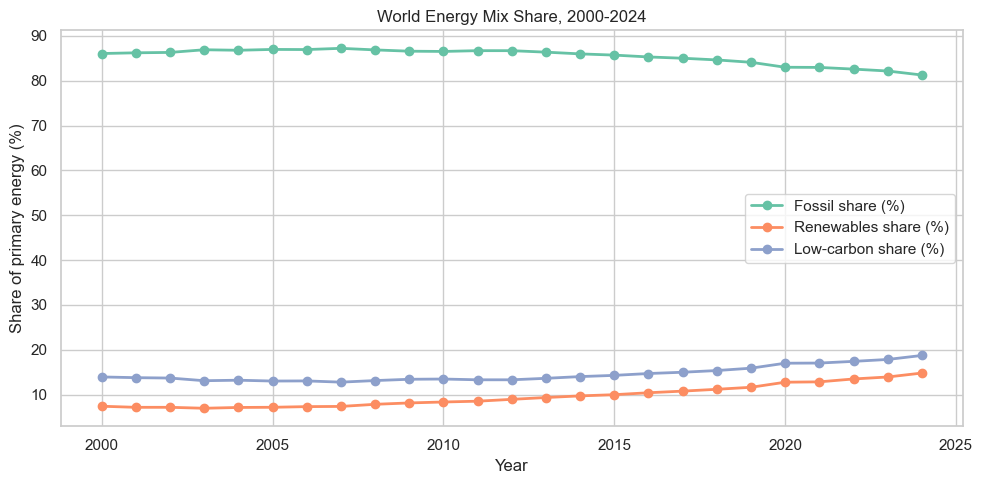

,year,primary_energy_consumption,fossil_share_energy,renewables_share_energy,low_carbon_share_energy
0,2000,110416.398,86.045,7.426,13.955
1,2010,141602.047,86.510,8.370,13.490
2,2020,157993.891,82.985,12.781,17.015
3,2024,176737.094,81.257,14.822,18.743


In [12]:
plt.figure(figsize=(10, 5))
plt.plot(world_recent['year'], world_recent['fossil_share_energy'], marker='o', linewidth=2, label='Fossil share (%)')
plt.plot(world_recent['year'], world_recent['renewables_share_energy'], marker='o', linewidth=2, label='Renewables share (%)')
plt.plot(world_recent['year'], world_recent['low_carbon_share_energy'], marker='o', linewidth=2, label='Low-carbon share (%)')
plt.title('World Energy Mix Share, 2000-2024')
plt.xlabel('Year')
plt.ylabel('Share of primary energy (%)')
plt.legend()
plt.tight_layout()
plt.show()

display(
    world_recent[world_recent['year'].isin([2000, 2010, 2020, 2024])][
        ['year', 'primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy', 'low_carbon_share_energy']
    ].reset_index(drop=True)
)

**Interpretation:** The world is moving toward a cleaner energy mix, but the change is quite slow. Fossil fuels still dominate global energy use, even though their share has decreased from about 86% in 2000 to around 81% in 2024.

At the same time, renewable energy has increased from about 7% to nearly 15%, which shows that the transition is happening. However, fossil fuels are still very important, so countries need to balance between reducing emissions and maintaining energy supply.


## Visualization 2: Which Countries Consume the Most Primary Energy in 2024

A ranked bar chart is useful for comparing magnitudes across countries in the latest year. This gives a quick view of where energy demand is concentrated.


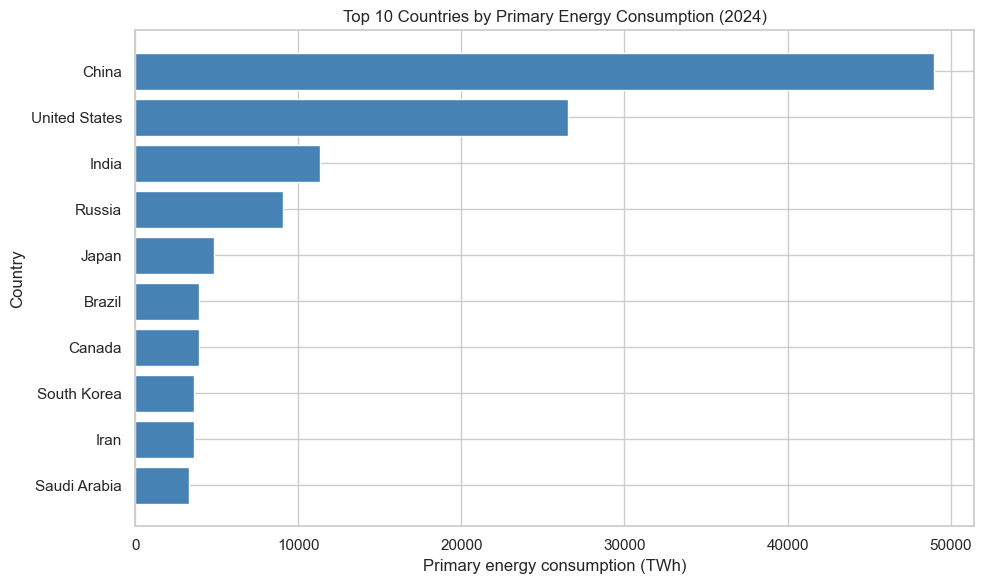

      country  primary_energy_consumption  fossil_share_energy  renewables_share_energy
 Saudi Arabia                     3290.42                99.27                     0.73
         Iran                     3589.79                98.07                     1.43
  South Korea                     3616.22                82.46                     4.75
       Canada                     3886.20                67.39                    27.16
       Brazil                     3919.05                49.38                    49.62
        Japan                     4794.82                82.96                    12.70
       Russia                     9049.15                88.16                     6.00
        India                    11336.06                89.67                     9.15
United States                    26528.61                80.33                    12.05
        China                    48987.10                80.26                    17.47


In [13]:
top10 = latest_df.nlargest(10, 'primary_energy_consumption').sort_values('primary_energy_consumption')

plt.figure(figsize=(10, 6))
plt.barh(top10['country'], top10['primary_energy_consumption'], color='steelblue')
plt.title(f'Top 10 Countries by Primary Energy Consumption ({analysis_year})')
plt.xlabel('Primary energy consumption (TWh)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(top10[['country', 'primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy']].round(2).to_string(index=False))

**Interpretation:** Energy demand is mainly concentrated in a few large countries. China and the United States are far ahead, followed by India and Russia.

This means that global energy decisions are mostly influenced by these countries. It also shows that energy use is closely related to a country’s size, such as its population and level of industrial activity.


## Visualization 3: Energy Consumption Trends for the Largest Energy Users

A multi-line chart shows whether the biggest consuming countries are growing at the same speed or following different trajectories.


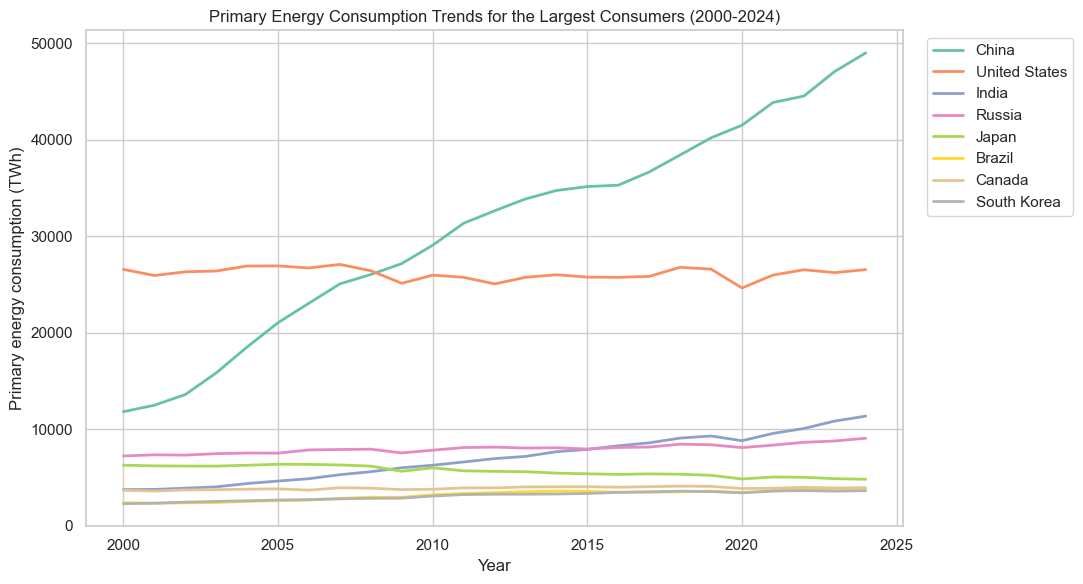

,country,year,primary_energy_consumption
0,Brazil,2000,2364.255
1,Brazil,2010,3188.735
2,Brazil,2020,3422.429
3,Brazil,2024,3919.054
4,Canada,2000,3647.490
5,Canada,2010,3760.554
6,Canada,2020,3834.944
7,Canada,2024,3886.195
8,China,2000,11800.284
9,China,2010,29055.609


In [14]:
plt.figure(figsize=(11, 6))
for country in trend_countries:
    sub = trend_df[trend_df['country'] == country]
    plt.plot(sub['year'], sub['primary_energy_consumption'], linewidth=2, label=country)

plt.title('Primary Energy Consumption Trends for the Largest Consumers (2000-2024)')
plt.xlabel('Year')
plt.ylabel('Primary energy consumption (TWh)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

latest_trend_table = trend_df[trend_df['year'].isin([2000, 2010, 2020, analysis_year])][['country', 'year', 'primary_energy_consumption']]
display(latest_trend_table.sort_values(['country', 'year']).reset_index(drop=True))

**Interpretation:** Energy growth trends are quite different across countries. China shows the fastest increase, which is linked to its rapid industrial and economic development. India is also growing quickly, while developed countries like Japan show a much slower trend.

This suggests that energy demand does not follow the same pattern everywhere. Different countries are at different stages of development, so their energy needs and policies should be considered separately.

## Visualization 4: Fossil vs Renewable Dependence in Selected Major Economies

A grouped bar chart helps compare energy structure across countries. Instead of looking only at total consumption, this graph asks how countries differ in their reliance on fossil fuels versus renewables.


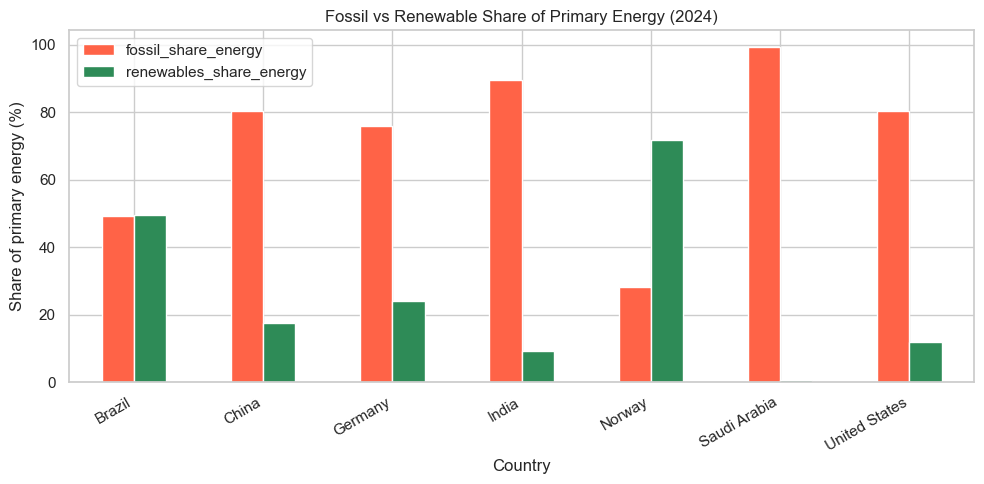

,country,primary_energy_consumption,fossil_share_energy,renewables_share_energy
0,China,48987.10,80.26,17.47
1,United States,26528.61,80.33,12.05
2,India,11336.06,89.67,9.15
3,Brazil,3919.05,49.38,49.62
4,Saudi Arabia,3290.42,99.27,0.73
5,Germany,3195.44,76.03,23.97
6,Norway,555.63,28.19,71.81


In [15]:
mix_plot = energy_mix_df[['country', 'fossil_share_energy', 'renewables_share_energy']].set_index('country')

ax = mix_plot.plot(kind='bar', figsize=(10, 5), color=['tomato', 'seagreen'])
ax.set_title(f'Fossil vs Renewable Share of Primary Energy ({analysis_year})')
ax.set_xlabel('Country')
ax.set_ylabel('Share of primary energy (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

display(energy_mix_df[['country', 'primary_energy_consumption', 'fossil_share_energy', 'renewables_share_energy']].round(2).sort_values('primary_energy_consumption', ascending=False).reset_index(drop=True))

**Interpretation:The selected countries show very different energy structures in 2024. Saudi Arabia and India rely heavily on fossil fuels, while Brazil and Norway have much higher renewable energy shares. China and the United States are both large energy consumers, but their energy mix is still dominated by fossil fuels.

This shows that high energy consumption does not necessarily mean a country has made strong progress in energy transition. Some countries are moving more clearly toward renewable energy, while others still depend mainly on fossil fuels.

## Visualization 5: GDP and Primary Energy Consumption

A scatter plot is appropriate for checking whether economically larger countries also consume more energy. Because country sizes vary enormously, a log scale makes the pattern easier to read.


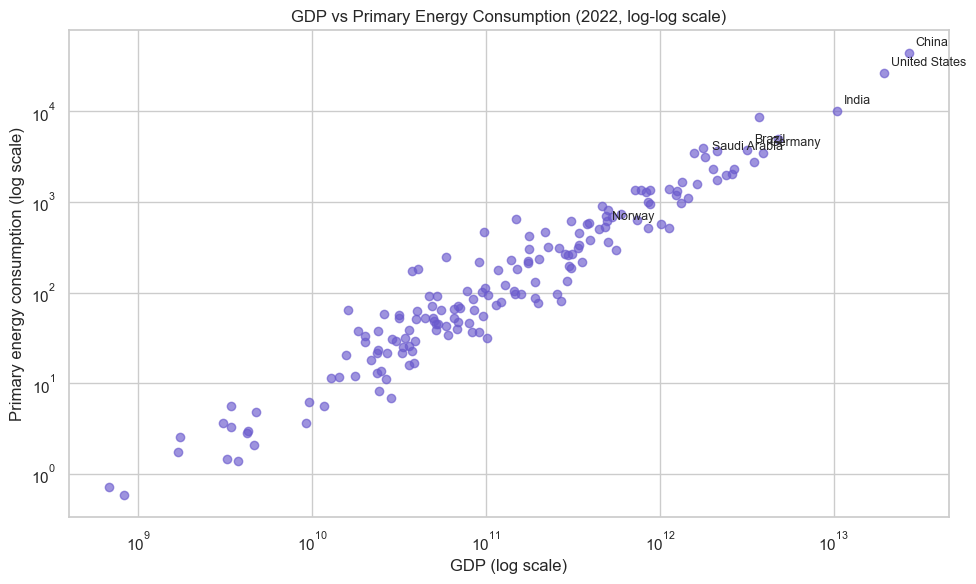

Correlation between GDP and primary energy consumption (2022): 0.982
Correlation between population and primary energy consumption (2022): 0.776


In [16]:
plot_df = gdp_df[['country', 'gdp', 'primary_energy_consumption', 'population']].copy()
plot_df = plot_df.dropna()
focus_countries = ['China', 'United States', 'India', 'Brazil', 'Germany', 'Saudi Arabia', 'Norway']

plt.figure(figsize=(10, 6))
plt.scatter(plot_df['gdp'], plot_df['primary_energy_consumption'], alpha=0.65, color='slateblue')

for country in focus_countries:
    sub = plot_df[plot_df['country'] == country]
    if not sub.empty:
        x = sub['gdp'].iloc[0]
        y = sub['primary_energy_consumption'].iloc[0]
        plt.annotate(country, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.xscale('log')
plt.yscale('log')
plt.title(f'GDP vs Primary Energy Consumption ({gdp_year}, log-log scale)')
plt.xlabel('GDP (log scale)')
plt.ylabel('Primary energy consumption (log scale)')
plt.tight_layout()
plt.show()

corr_value = plot_df[['gdp', 'primary_energy_consumption']].corr().iloc[0, 1]
pop_corr = plot_df[['population', 'primary_energy_consumption']].corr().iloc[0, 1]
print(f'Correlation between GDP and primary energy consumption ({gdp_year}): {corr_value:.3f}')
print(f'Correlation between population and primary energy consumption ({gdp_year}): {pop_corr:.3f}')

**Interpretation:** The scatter plot shows a clear positive relationship between GDP and energy consumption. Countries with larger economies usually use more energy because they produce more goods and have more activities.

Population also plays a role, but economic size seems to be more important here. This suggests that energy demand is closely linked to economic growth, so future energy planning should consider how the economy changes over time.


 Conclusion

This corrected Lab 2 notebook uses the right dataset and shows that global energy demand is highly concentrated in a few major economies, while the energy transition remains uneven across countries. The world energy mix is gradually becoming cleaner, but fossil fuels still dominate. Economic scale strongly relates to total energy demand, and countries with similar consumption levels can still have very different renewable and fossil shares.
